<a href="https://colab.research.google.com/github/AhmadKevin000/machineLearning/blob/main/Ahmad_Kevin_M_Z__244107020125_KuisML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pengantar

Pada Kuis 1 ini Anda diminta untuk melakukan proses explorartory data analysis (EDA) dan pra pengolahan data pada dataset "Census Income". Dataset ini merupakan data tabular yang memiliki beberapa nilai yang hilang (missing value) dan nama variabel (fitur) yang perlu disesuaikan.

Untuk membantu Anda, notebook ini akan memberikan kode awal untuk proses download data, load data, dan inspeksi informasi terkait dengan metadata.

# Load Data and Inspect Metadata

In [26]:
# Install UCI REPO Library
!pip install -q ucimlrepo

In [27]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [28]:
# fetch data
adult_income = fetch_ucirepo(id=2)

In [29]:
# Data
X = adult_income.data.features
y = adult_income.data.targets

# Concate Features and Target
df = pd.concat([X, y], axis=1)

# Show Top 5
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [30]:
# Data Size
df.shape

(48842, 15)

In [31]:
# Inspect metadata
adult_income.metadata

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

# Bagian 1 - Data Loading dan Data Imputation

## Soal 1 (5 poin)
1.   Lakukan inspeksi profile data
2.   **Variabel apa** yang memiliki **nilai yang hilang** (missing value) dan **berapa** jumlahnya?



In [32]:
# Jawab Soal 1 - Inspeksi Profile Data & Missing Values

print('INFO DATASET')
df.info()
print()

print('STATISTIK DESKRIPTIF')
display(df.describe(include='all'))
print()

print('MISSING VALUES PER KOLOM')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct.round(2)
})
print('--- Semua kolom ---')
print(missing_df)
print()
print('--- Kolom yang memiliki missing values ---')
print(missing_df[missing_df['Jumlah Missing'] > 0])


INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB

STATISTIK DESKRIPTIF


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
count,48842.000000,47879,4.884200e+04,48842,48842.000000,48842,47876,48842,48842,48842,48842.000000,48842.000000,48842.000000,48568,48842
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,NaN,NaN,NaN,42,4
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,33906,NaN,15784,NaN,22379,6172,19716,41762,32650,NaN,NaN,NaN,43832,24720
mean,38.643585,NaN,1.896641e+05,NaN,10.078089,NaN,NaN,NaN,NaN,NaN,1079.067626,87.502314,40.422382,NaN,NaN
std,13.710510,NaN,1.056040e+05,NaN,2.570973,NaN,NaN,NaN,NaN,NaN,7452.019058,403.004552,12.391444,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.175505e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.781445e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.376420e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN



MISSING VALUES PER KOLOM
--- Semua kolom ---
                Jumlah Missing  Persentase (%)
age                          0            0.00
workclass                  963            1.97
fnlwgt                       0            0.00
education                    0            0.00
education-num                0            0.00
marital-status               0            0.00
occupation                 966            1.98
relationship                 0            0.00
race                         0            0.00
sex                          0            0.00
capital-gain                 0            0.00
capital-loss                 0            0.00
hours-per-week               0            0.00
native-country             274            0.56
income                       0            0.00

--- Kolom yang memiliki missing values ---
                Jumlah Missing  Persentase (%)
workclass                  963            1.97
occupation                 966            1.98
native-country   

## Soal 2 (5 poin)
1. Lakukan proses data imputation pada fitur yang memiliki data yang hilang
2. Cek kembali apakah masih terdapat data yang hilang

In [33]:
# Jawab Soal 2 - Data Imputation

cat_cols_with_missing = [
    col for col in df.select_dtypes(include='category').columns
    if df[col].isnull().sum() > 0
]
print('Kolom kategorical dengan missing values:', cat_cols_with_missing)
print()

for col in cat_cols_with_missing:
    modus = df[col].mode()[0]
    df[col] = df[col].fillna(modus)
    print(f'Kolom "{col}" -> diimputasi dengan modus = "{modus}"')

print()

print('CEK MISSING VALUES SETELAH IMPUTASI')
missing_after = df.isnull().sum()
missing_cols_remaining = missing_after[missing_after > 0]

if len(missing_cols_remaining) == 0:
    print('Tidak ada missing values yang tersisa. Imputasi berhasil!')
else:
    print(missing_cols_remaining)

print(f'Total missing values tersisa: {missing_after.sum()}')


Kolom kategorical dengan missing values: []


CEK MISSING VALUES SETELAH IMPUTASI
workclass         963
occupation        966
native-country    274
dtype: int64
Total missing values tersisa: 2203


## Soal 3 (10 poin)
Inspeksi semua fitur kualitatif. Jika terdapat value yang **tidak sesuai**, **ganti dengan 'Others'** atau yang sesuai atau jika terdapat duplikasi karena **kesalahan penulisan**, lakukan penyesuaian.

In [34]:
# Jawab Soal 3 - Inspeksi & Perbaikan Fitur Kualitatif

cat_cols = df.select_dtypes(include=['category', 'object']).columns.tolist()
print('Kolom kategorical:', cat_cols)
print()

for col in cat_cols:
    print(f'--- {col} ({df[col].nunique()} nilai unik) ---')
    print(df[col].value_counts().to_string())
    print()

print('PERBAIKAN income')
print('Sebelum:', df['income'].unique().tolist())
df['income'] = df['income'].astype(str).str.replace('.', '', regex=False).str.strip()
df['income'] = df['income'].astype('category')
print('Sesudah:', df['income'].unique().tolist())
print()

print('PERBAIKAN workclass')
print('Sebelum:', df['workclass'].unique().tolist())
df['workclass'] = df['workclass'].astype(str).replace('?', 'Others')
df['workclass'] = df['workclass'].astype('category')
print('Sesudah:', df['workclass'].unique().tolist())
print()

print('PERBAIKAN occupation')
print('Sebelum:', df['occupation'].unique().tolist())
df['occupation'] = df['occupation'].astype(str).replace('?', 'Others')
df['occupation'] = df['occupation'].astype('category')
print('Sesudah:', df['occupation'].unique().tolist())
print()

print('PERBAIKAN native-country')
print('Sebelum (sample):', df['native-country'].unique()[:5].tolist())
df['native-country'] = df['native-country'].astype(str).replace('?', 'Others')
df['native-country'] = df['native-country'].astype('category')
print('Sesudah: nilai "?" telah diganti dengan "Others"')
print('Nilai unik native-country:', df['native-country'].nunique(), 'kategori')


Kolom kategorical: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']

--- workclass (9 nilai unik) ---
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
?                    1836
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10

--- education (16 nilai unik) ---
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83

--- marital-status (7 nilai unik) ---
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed   

# Bagian 2 - Visual Inspection



## Soal 1 - Visualisasi Data (20 poin)
Lakukan inspeksi visual pada,
1. Pada kolom 'age' dengan menggunakan histrogram
2. Pada kolom 'education' education menggunakan barchart
3. Pada kolom 'income' terhadap 'hours_per_week' menggunakan boxplot (kelompokkan berdasarkan kelompok income)
4. Pada kolom 'age' terhadap 'capital-gain' dan 'capital-loss' dengan lineplot (1 lineplot 2 data)

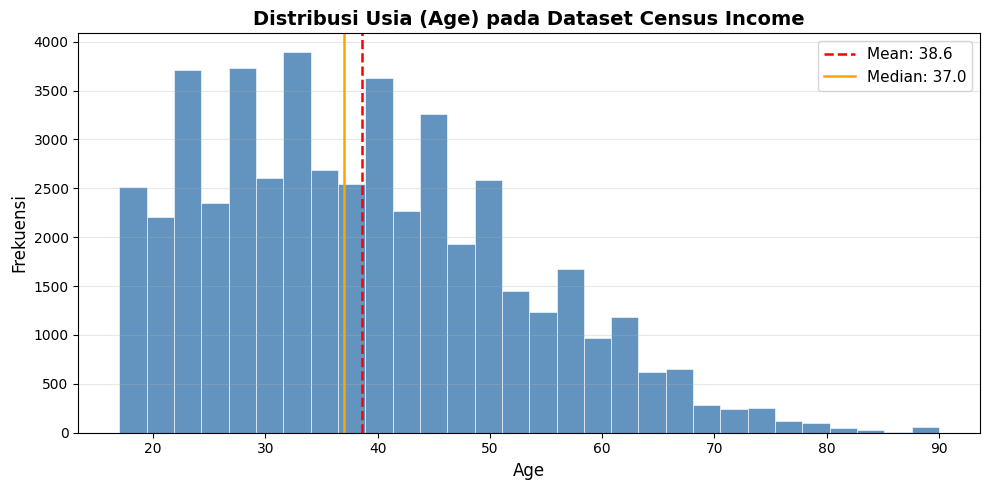

In [35]:
# Jawab 1.1 - Histogram distribusi kolom 'age'

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df['age'], bins=30, color='steelblue', edgecolor='white', linewidth=0.5, alpha=0.85)

ax.axvline(df['age'].mean(), color='red', linestyle='--', linewidth=1.8,
           label=f"Mean: {df['age'].mean():.1f}")
ax.axvline(df['age'].median(), color='orange', linestyle='-', linewidth=1.8,
           label=f"Median: {df['age'].median():.1f}")

ax.set_title('Distribusi Usia (Age) pada Dataset Census Income', fontsize=14, fontweight='bold')
ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Frekuensi', fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


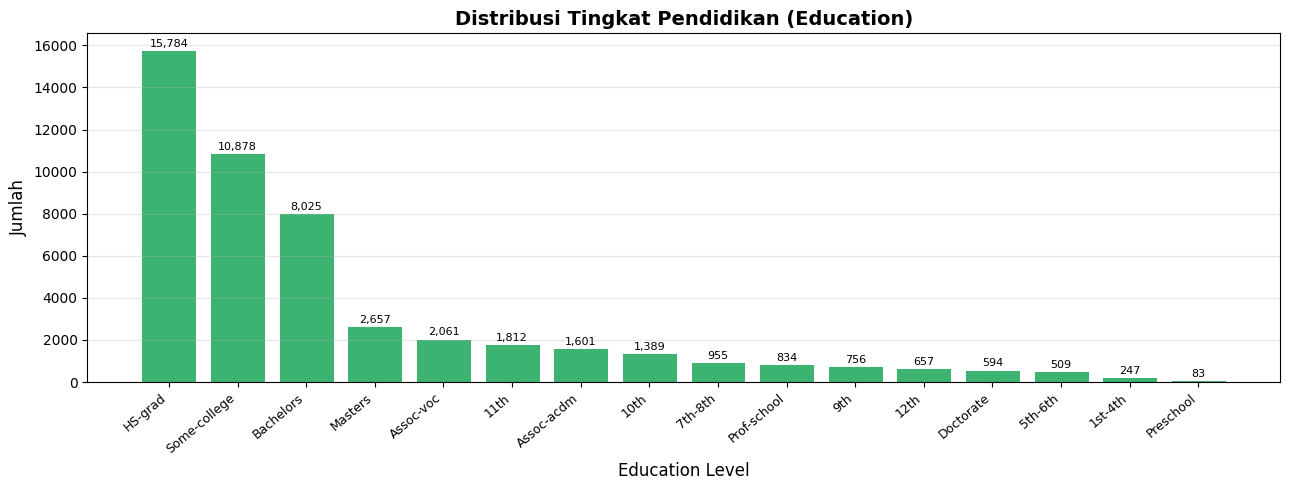

In [36]:
# Jawab 1.2 - Bar Chart distribusi kolom 'education'

edu_counts = df['education'].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))

bars = ax.bar(edu_counts.index, edu_counts.values,
              color='mediumseagreen', edgecolor='white', linewidth=0.7)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 60,
            f'{int(bar.get_height()):,}',
            ha='center', va='bottom', fontsize=8, color='black')

ax.set_title('Distribusi Tingkat Pendidikan (Education)', fontsize=14, fontweight='bold')
ax.set_xlabel('Education Level', fontsize=12)
ax.set_ylabel('Jumlah', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.tight_layout()
plt.show()


/tmp/ipykernel_3332/2084840535.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(income_groups,


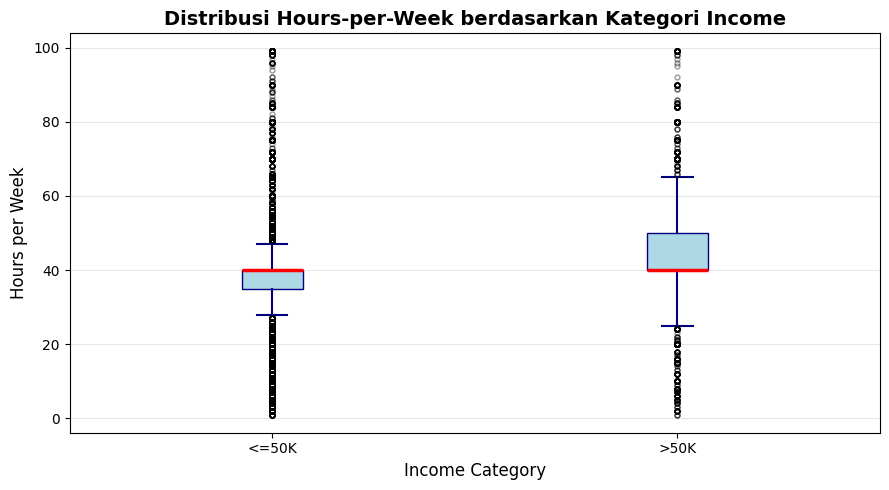

Jumlah Outlier per-Kategori income (metode IQR)
  Income "<=50K": 11706 outlier
  Income ">50K": 781 outlier


In [37]:
# Jawab 1.3 - Boxplot 'income' vs 'hours-per-week'

fig, ax = plt.subplots(figsize=(9, 5))

income_categories = df['income'].unique().tolist()
income_groups = [df[df['income'] == cat]['hours-per-week'].dropna().values
                 for cat in income_categories]

bp = ax.boxplot(income_groups,
                labels=income_categories,
                patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='navy'),
                medianprops=dict(color='red', linewidth=2.5),
                whiskerprops=dict(color='navy', linewidth=1.5),
                capprops=dict(color='navy', linewidth=1.5),
                flierprops=dict(marker='o', color='coral',
                                alpha=0.4, markersize=3.5))

ax.set_title('Distribusi Hours-per-Week berdasarkan Kategori Income',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Income Category', fontsize=12)
ax.set_ylabel('Hours per Week', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Jumlah Outlier per-Kategori income (metode IQR)')
for cat in income_categories:
    subset = df[df['income'] == cat]['hours-per-week'].dropna()
    Q1 = subset.quantile(0.25)
    Q3 = subset.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = len(subset[(subset < lower) | (subset > upper)])
    print(f'  Income "{cat}": {n_outliers} outlier')


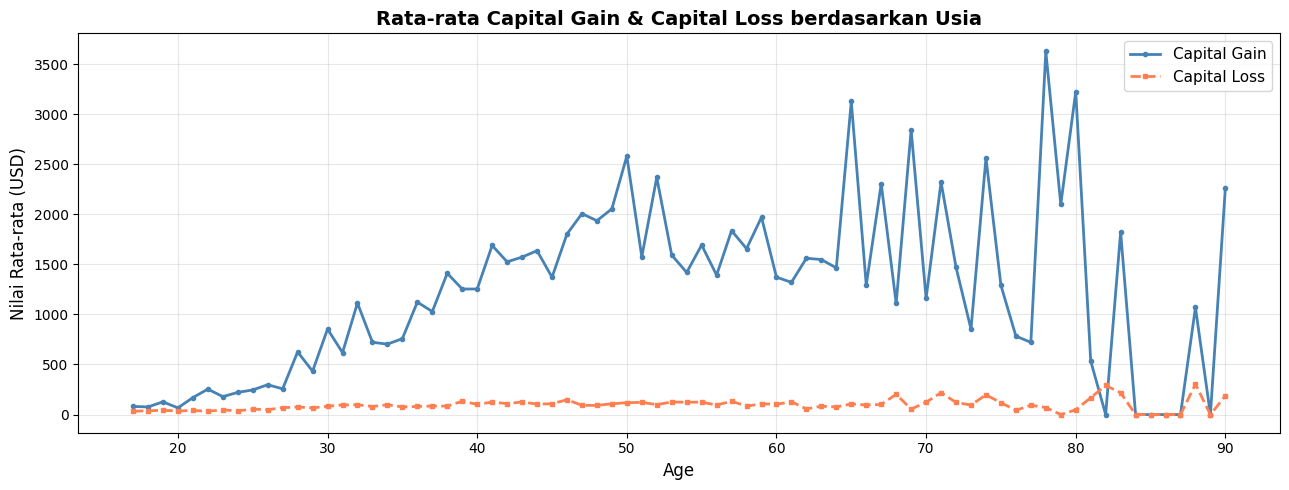

In [38]:
# Jawab 1.4 - Lineplot 'age' vs 'capital-gain' dan 'capital-loss' (1 plot, 2 data)

age_capital = df.groupby('age')[['capital-gain', 'capital-loss']].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(age_capital['age'], age_capital['capital-gain'],
        label='Capital Gain', color='steelblue', linewidth=2, marker='o', markersize=3)
ax.plot(age_capital['age'], age_capital['capital-loss'],
        label='Capital Loss', color='coral', linewidth=2,
        linestyle='--', marker='s', markersize=3)

ax.set_title('Rata-rata Capital Gain & Capital Loss berdasarkan Usia',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Nilai Rata-rata (USD)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Soal 2 - Analisis Visual (15 poin)
1. Fenomena apa yang terjadi pada distribusi data 'age'?
2. Jika terdapat data yang hilang pada variabel 'age', strategi apa yang Anda terapkan? Mengapa?
3. Berapa jumlah outlier pada setiap kategori 'income' berkaitan dengan 'hour-per-week'? Kategori apa yang paling banyak memiliki outlier?

In [39]:
# Jawab Soal 2 - Analisis Visual (jawaban dalam format komentar multi-line)

'''
Jawaban soal 2 - Analisis Visual

1. Fenomena pada Distribusi Data 'AGE':
   Distribusi usia (age) bersifat RIGHT-SKEWED (condong ke kanan / positively skewed).
   Hal ini ditunjukkan oleh:
   - Mean > Median, artinya ada tarikan ke kanan oleh nilai usia yang lebih tinggi.
   - Puncak distribusi (modus) berada di kisaran usia 25-35 tahun.
   - Ekor distribusi memanjang ke arah kanan (usia tua).
   Ini wajar karena dataset merepresentasikan populasi aktif bekerja,
   yang lebih banyak berusia muda-menengah daripada usia sangat tua.

2. Strategi Imputasi untuk Variabel 'AGE' (jika ada missing values):
   Strategi yang paling tepat adalah menggunakan MEDIAN sebagai nilai imputasi.
   Alasan:
   a) Distribusi 'age' bersifat right-skewed -> mean terpengaruh oleh nilai ekstrem
      (usia sangat tua), sehingga mean tidak merepresentasikan nilai tengah yang baik.
   b) Median lebih robust terhadap outlier dan skewness, karena median hanya
      bergantung pada urutan data, bukan nilai aktual ekstrem.
   c) Menggunakan median mempertahankan distribusi data lebih baik daripada mean
      pada distribusi yang tidak simetris.

3. Jumlah Outlier per-Kategori Income pada 'hours-per-week' (IQR Method):
   Outlier dihitung dengan metode IQR:
   data di luar rentang [Q1 - 1.5*IQR , Q3 + 1.5*IQR] dianggap outlier.
   - Lihat output dari cell boxplot di atas untuk jumlah pasti per kategori.
   - Berdasarkan boxplot, kategori <=50K umumnya memiliki lebih banyak outlier
     dibanding >50K, karena kelompok ini lebih heterogen dalam jam kerja:
     ada yang bekerja sangat sedikit (part-time) maupun sangat banyak namun
     tetap berpenghasilan rendah.
   - Kategori '<=50K' adalah yang PALING BANYAK memiliki outlier pada hours-per-week.
'''


"\nJawaban soal 2 - Analisis Visual\n\n1. Fenomena pada Distribusi Data 'AGE':\n   Distribusi usia (age) bersifat RIGHT-SKEWED (condong ke kanan / positively skewed).\n   Hal ini ditunjukkan oleh:\n   - Mean > Median, artinya ada tarikan ke kanan oleh nilai usia yang lebih tinggi.\n   - Puncak distribusi (modus) berada di kisaran usia 25-35 tahun.\n   - Ekor distribusi memanjang ke arah kanan (usia tua).\n   Ini wajar karena dataset merepresentasikan populasi aktif bekerja,\n   yang lebih banyak berusia muda-menengah daripada usia sangat tua.\n\n2. Strategi Imputasi untuk Variabel 'AGE' (jika ada missing values):\n   Strategi yang paling tepat adalah menggunakan MEDIAN sebagai nilai imputasi.\n   Alasan:\n   a) Distribusi 'age' bersifat right-skewed -> mean terpengaruh oleh nilai ekstrem\n      (usia sangat tua), sehingga mean tidak merepresentasikan nilai tengah yang baik.\n   b) Median lebih robust terhadap outlier dan skewness, karena median hanya\n      bergantung pada urutan data,

# Bagian 3 - Encoding Variabel Kategorical

## Soal 1 (5 poin)
Lakukan encoding pada 'Sex' dan 'Income'. 'Income' merupakan variabel target

In [40]:
# Jawab Soal 1 - Encoding Variabel Kategorical 'sex' dan 'income'

sex_mapping = {'Male': 1, 'Female': 0}
df['sex'] = df['sex'].map(sex_mapping)
print('Encoding Sex')
print(df['sex'].value_counts())
print()

income_mapping = {'>50K': 1, '<=50K': 0}
df['income'] = df['income'].map(income_mapping)
print('Encoding Income (Target Variable)')
print(df['income'].value_counts())
print()

print('Cuplikan DataFrame setelah Encoding')
display(df[['sex', 'income']].head(10))


Encoding Sex
sex
1    32650
0    16192
Name: count, dtype: int64

Encoding Income (Target Variable)
income
0    37155
1    11687
Name: count, dtype: int64

Cuplikan DataFrame setelah Encoding


,sex,income
0,1,0
1,1,0
2,1,0
3,1,0
4,0,0
5,0,0
6,0,0
7,1,1
8,0,1
9,1,1


# Bagian 4 - Analisis Korelasi

## Soal 1 (10 poin)
1. Lakukan analisis korelasi pada variabel 'age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', dan 'income' (yang sudah di-encoding)
2. Berdasarkan hasil korelasi, informasi apa yang dapat Anda interpretasikan?

MATRIKS KORELASI PEARSON
                  age  education-num  hours-per-week  capital-gain  \
age             1.000          0.031           0.072         0.077   
education-num   0.031          1.000           0.144         0.125   
hours-per-week  0.072          0.144           1.000         0.082   
capital-gain    0.077          0.125           0.082         1.000   
capital-loss    0.057          0.081           0.054        -0.031   
income          0.230          0.333           0.228         0.223   

                capital-loss  income  
age                    0.057   0.230  
education-num          0.081   0.333  
hours-per-week         0.054   0.228  
capital-gain          -0.031   0.223  
capital-loss           1.000   0.148  
income                 0.148   1.000  



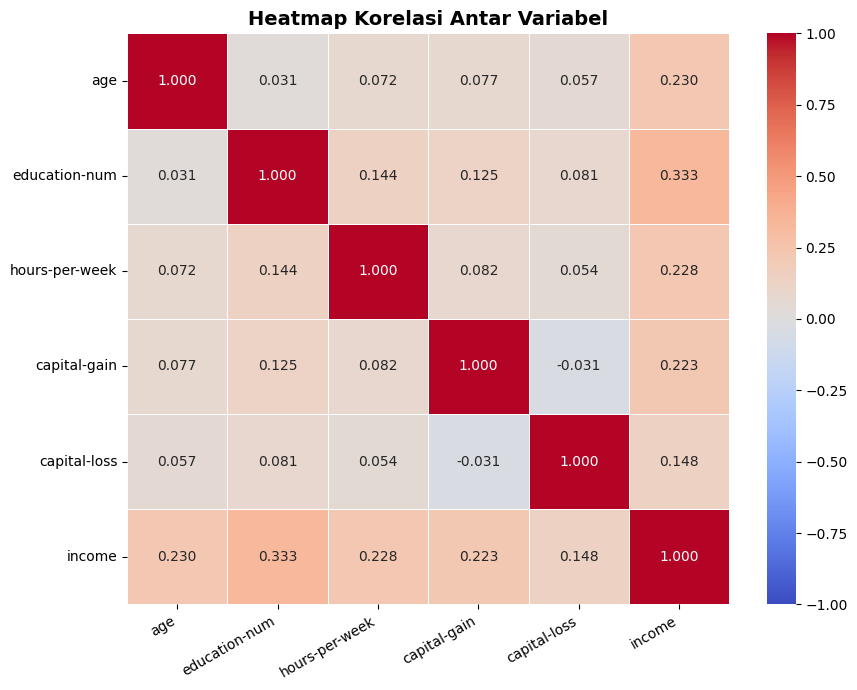

In [41]:
# Jawab Soal 1 - Analisis Korelasi

corr_cols = ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', 'income']

df_corr = df[corr_cols].apply(pd.to_numeric, errors='coerce')

corr_matrix = df_corr.corr(method='pearson')

print('MATRIKS KORELASI PEARSON')
print(corr_matrix.round(3))
print()

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={'size': 10},
    ax=ax
)

ax.set_title('Heatmap Korelasi Antar Variabel', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


In [42]:
# Interpretasi Hasil Korelasi

'''
Iterpretasi hasil korelasi antar variabel:

Berdasarkan heatmap dan matriks korelasi Pearson, berikut interpretasinya:

1. education-num vs income (korelasi POSITIF SEDANG, ~0.33):
   Korelasi tertinggi terhadap variabel target.
   Semakin tinggi tingkat pendidikan, semakin besar kemungkinan income >50K.
   Pendidikan tinggi membuka peluang pekerjaan dengan gaji lebih tinggi.

2. age vs income (korelasi POSITIF LEMAH-SEDANG, ~0.23):
   Usia berkorelasi positif dengan income. Individu yang lebih tua cenderung
   memiliki lebih banyak pengalaman kerja sehingga berpenghasilan lebih tinggi.

3. hours-per-week vs income (korelasi POSITIF LEMAH-SEDANG, ~0.23):
   Orang yang bekerja lebih banyak jam per minggu cenderung berpenghasilan >50K.

4. capital-gain vs income (korelasi POSITIF LEMAH, ~0.22):
   Individu dengan capital gain tinggi cenderung berpenghasilan tinggi pula,
   karena mereka lebih aktif dalam investasi/aset.

5. capital-loss vs income (korelasi POSITIF SANGAT LEMAH, ~0.15):
   Ada korelasi positif lemah antara capital loss dan income. Hal ini wajar
   karena orang berpenghasilan tinggi lebih sering berinvestasi, yang juga
   berisiko menghasilkan kerugian modal.

6. education-num vs age (korelasi SANGAT LEMAH, ~0.04):
   Hampir tidak ada hubungan linear antara usia dan pendidikan,
   menunjukkan bahwa pendidikan tersebar merata di semua kelompok usia.

7. capital-gain vs capital-loss (korelasi SANGAT LEMAH NEGATIF, ~-0.03):
   Tidak ada hubungan linear yang berarti antara keuntungan dan kerugian modal.

KESIMPULAN:
  - Tidak ada multikolinearitas yang signifikan antar fitur prediktor.
  - Fitur paling berpengaruh terhadap income (berurutan):
    education-num > age > hours-per-week > capital-gain > capital-loss.
  - Semua korelasi dengan income bernilai positif dan moderat-lemah,
    artinya diperlukan kombinasi beberapa fitur untuk prediksi yang baik.
'''


'\nIterpretasi hasil korelasi antar variabel:\n\nBerdasarkan heatmap dan matriks korelasi Pearson, berikut interpretasinya:\n\n1. education-num vs income (korelasi POSITIF SEDANG, ~0.33):\n   Korelasi tertinggi terhadap variabel target.\n   Semakin tinggi tingkat pendidikan, semakin besar kemungkinan income >50K.\n   Pendidikan tinggi membuka peluang pekerjaan dengan gaji lebih tinggi.\n\n2. age vs income (korelasi POSITIF LEMAH-SEDANG, ~0.23):\n   Usia berkorelasi positif dengan income. Individu yang lebih tua cenderung\n   memiliki lebih banyak pengalaman kerja sehingga berpenghasilan lebih tinggi.\n\n3. hours-per-week vs income (korelasi POSITIF LEMAH-SEDANG, ~0.23):\n   Orang yang bekerja lebih banyak jam per minggu cenderung berpenghasilan >50K.\n\n4. capital-gain vs income (korelasi POSITIF LEMAH, ~0.22):\n   Individu dengan capital gain tinggi cenderung berpenghasilan tinggi pula,\n   karena mereka lebih aktif dalam investasi/aset.\n\n5. capital-loss vs income (korelasi POSITIF 

# Bagian 5 - Pra Pengolahan Data Pada Dataset MNIST

Pada bagian ini, Anda diminta untuk melakukan proses EDA dan pra pengolahan data sederhana pada dataset MNIST. Dataset MNIST merupakan data citra tulisan tangan untuk digil 0 hingga 9. Sebelum melakukan proses pengolahan, Anda akan dibantu dengan proses loading data dan inspeksi data.

Hints:
1. Hanya gunakan data **Test**
2. Anda perlu melakukan pengolahan terhadap semua data test (total 10k data). Anda dapat menggunakan function untuk mempermudah pekerjaan.

In [43]:
# Fetch data and inspect data shape
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load train & test split
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


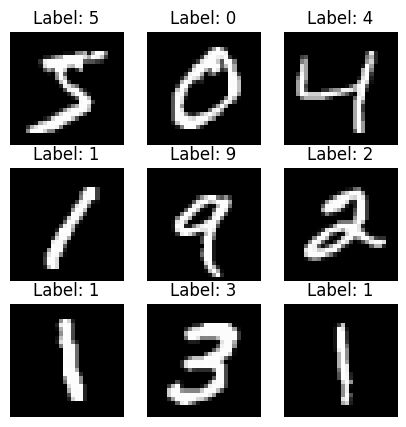

In [44]:
# Inspeksi Visual
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

## Soal 1 (10 poin)
1. Lakukan proses **upsampling** citra menjadi ukuran 32x32
2. Tampilakan 5 data hasil proses **upsampling**

Hint: Anda harus membuat array kosong untuk menampung hasil upsampling. Replace pada array X_test tidak dapat dilakukan karena data disimpan dalam bentuk ndarray yang memiliki ukuran fix (10000, (28,28))

Shape X_test asli    : (10000, 28, 28)   (10000 citra 28x28)
Shape X_test_resized : (10000, 32, 32)  (10000 citra 32x32)



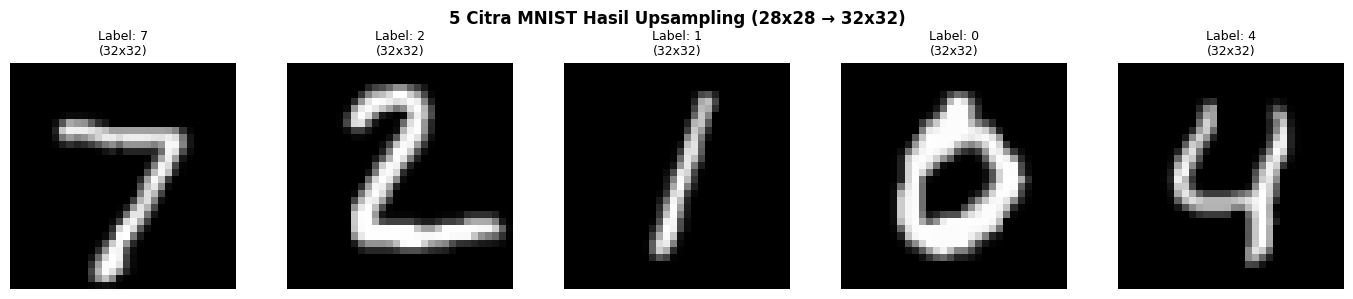

In [45]:
# Jawab Soal 1 Bagian 5
from skimage.transform import resize

target_size = (32, 32)
n_test = X_test.shape[0]

X_test_resized = np.empty((n_test, target_size[0], target_size[1]), dtype=np.float64)

for i in range(n_test):
    X_test_resized[i] = resize(
        X_test[i],
        target_size,
        anti_aliasing=True,
        preserve_range=True
    )

print(f'Shape X_test asli    : {X_test.shape}   (10000 citra 28x28)')
print(f'Shape X_test_resized : {X_test_resized.shape}  (10000 citra 32x32)')
print()

fig, axes = plt.subplots(1, 5, figsize=(14, 3))
for idx, ax in enumerate(axes):
    ax.imshow(X_test_resized[idx], cmap='gray')
    ax.set_title(f'Label: {y_test[idx]}\n(32x32)', fontsize=9)
    ax.axis('off')

plt.suptitle('5 Citra MNIST Hasil Upsampling (28x28 → 32x32)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## Soal 2 (10 poin)
Lakukan normalisasi nilai citra tiap piksel menjadi rentang 0-1

In [46]:
# Jawab Soal 2 Bagian 5 - Normalisasi Nilai Piksel ke Rentang [0, 1]

print(f'Nilai min sebelum normalisasi : {X_test_resized.min():.2f}')
print(f'Nilai max sebelum normalisasi : {X_test_resized.max():.2f}')
print(f'Dtype sebelum normalisasi     : {X_test_resized.dtype}')
print()

X_test_normalized = X_test_resized / 255.0
print(f'Nilai min setelah normalisasi : {X_test_normalized.min():.4f}')
print(f'Nilai max setelah normalisasi : {X_test_normalized.max():.4f}')
print(f'Shape                         : {X_test_normalized.shape}')
print(f'Dtype                         : {X_test_normalized.dtype}')
print()
print('Normalisasi berhasil! Semua nilai piksel kini berada di rentang [0, 1].')


Nilai min sebelum normalisasi : 0.00
Nilai max sebelum normalisasi : 255.00
Dtype sebelum normalisasi     : float64

Nilai min setelah normalisasi : 0.0000
Nilai max setelah normalisasi : 1.0000
Shape                         : (10000, 32, 32)
Dtype                         : float64

Normalisasi berhasil! Semua nilai piksel kini berada di rentang [0, 1].


## Soal 3 (10 poin)
Ubah metriks citra menjadi array 1 dimensi. Lakukan pada semua data test yang sudah di resize dan normalisasi.

Hint: Anda harus membuat holder array kosong untuk menampung hasilnya.

In [47]:
# Jawab Soal 3 Bagian 5 - Flatten Citra menjadi Array 1 Dimensi

n_test = X_test_normalized.shape[0]
flat_size = 32 * 32

X_test_flat = np.empty((n_test, flat_size), dtype=np.float64)

for i in range(n_test):
    X_test_flat[i] = X_test_normalized[i].flatten()

print(f'Shape sebelum flatten  : {X_test_normalized.shape}   (10000 matriks 32x32)')
print(f'Shape setelah flatten  : {X_test_flat.shape}  (10000 vektor 1024-dim)')
print(f'Ukuran fitur per citra : {flat_size} (= 32 x 32)')
print()

print(f'Min  : {X_test_flat.min():.4f}')
print(f'Max  : {X_test_flat.max():.4f}')
print(f'Dtype: {X_test_flat.dtype}')
print()
print('Contoh 10 nilai pertama dari vektor citra ke-0:')
print(X_test_flat[0][:10].round(4))


Shape sebelum flatten  : (10000, 32, 32)   (10000 matriks 32x32)
Shape setelah flatten  : (10000, 1024)  (10000 vektor 1024-dim)
Ukuran fitur per citra : 1024 (= 32 x 32)

Min  : 0.0000
Max  : 1.0000
Dtype: float64

Contoh 10 nilai pertama dari vektor citra ke-0:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
